In [2]:
!pip install pymc arviz pandas matplotlib seaborn

In [3]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

np.random.seed(42)

In [4]:
# parameter
n_claims = 5000
n_workshops = 50

# workshop ID
workshop_id = np.random.randint(0, n_workshops, n_claims)

# latent fraud workshop effect
true_workshop_risk = np.random.normal(0, 0.7, n_workshops)

# beberapa workshop sangat fraud
fraud_workshops = [5, 12, 18, 27, 41]

for w in fraud_workshops:
    true_workshop_risk[w] += 2.5

# variabel klaim
claim_amount = np.random.gamma(2, 3000, n_claims)

vehicle_age = np.random.randint(0, 15, n_claims)

claim_delay = np.random.poisson(5, n_claims)

# logistic fraud probability
logit_p = (
    -5
    + 0.00015 * claim_amount
    + 0.08 * vehicle_age
    + 0.12 * claim_delay
    + true_workshop_risk[workshop_id]
)

p_fraud = 1 / (1 + np.exp(-logit_p))

fraud = np.random.binomial(1, p_fraud)

# dataset
df = pd.DataFrame({
    "claim_amount": claim_amount,
    "vehicle_age": vehicle_age,
    "claim_delay": claim_delay,
    "workshop_id": workshop_id,
    "fraud": fraud
})

df.head()

,claim_amount,vehicle_age,claim_delay,workshop_id,fraud
0,9449.405412,4,2,38,0
1,10415.751605,6,11,28,0
2,4035.888062,6,11,14,0
3,6420.910021,14,12,42,0
4,10232.457765,3,5,7,0


In [5]:
print(df["fraud"].mean())

0.1278


In [6]:
df["claim_amount_std"] = (
    df["claim_amount"] - df["claim_amount"].mean()
) / df["claim_amount"].std()

df["vehicle_age_std"] = (
    df["vehicle_age"] - df["vehicle_age"].mean()
) / df["vehicle_age"].std()

df["claim_delay_std"] = (
    df["claim_delay"] - df["claim_delay"].mean()
) / df["claim_delay"].std()

In [7]:
workshop_idx = df["workshop_id"].values
n_workshops = df["workshop_id"].nunique()

with pm.Model() as fraud_model:

    # priors
    beta0 = pm.Normal("beta0", 0, 1)

    beta_claim = pm.Normal("beta_claim", 0, 1)
    beta_age = pm.Normal("beta_age", 0, 1)
    beta_delay = pm.Normal("beta_delay", 0, 1)

    # hierarchical workshop effect
    sigma_workshop = pm.Exponential("sigma_workshop", 1)

    # non-centered parameterization
    workshop_raw = pm.Normal(
        "workshop_raw",
        0,
        1,
        shape=n_workshops
    )

    workshop_effect = pm.Deterministic(
        "workshop_effect",
        workshop_raw * sigma_workshop
    )

    # linear predictor
    logit_p = (
        beta0
        + beta_claim * df["claim_amount_std"].values
        + beta_age * df["vehicle_age_std"].values
        + beta_delay * df["claim_delay_std"].values
        + workshop_effect[workshop_idx]
    )

    # fraud probability
    p = pm.math.sigmoid(logit_p)

    # likelihood
    fraud_obs = pm.Bernoulli(
        "fraud_obs",
        p=p,
        observed=df["fraud"].values
    )

    # sampling
    trace = pm.sample(
        2000,
        tune=2000,
        target_accept=0.95,
        random_seed=42
    )

Output()

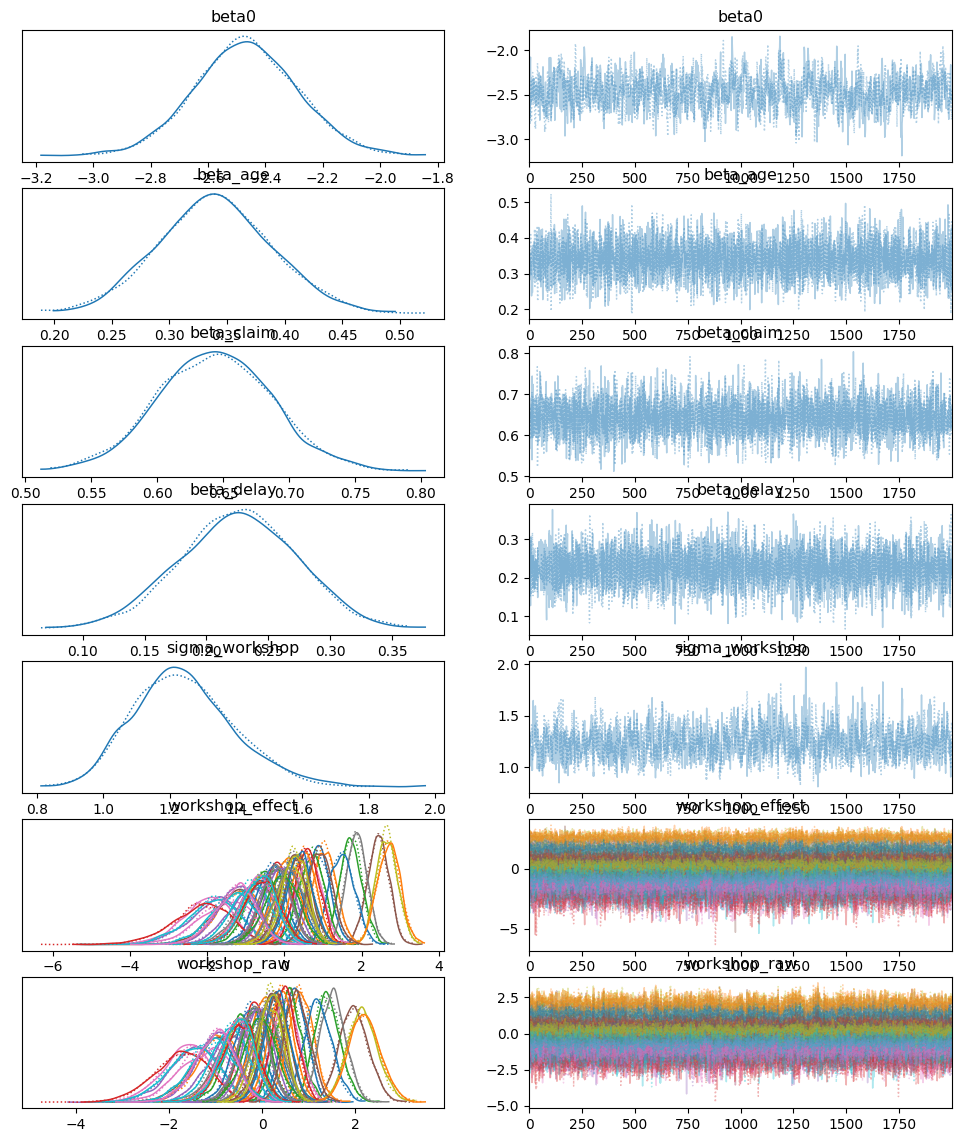

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
beta0,-2.467,0.180,-2.794,-2.120,0.007,0.004,653.0,1086.0,1.00
beta_age,0.340,0.049,0.250,0.437,0.001,0.001,6017.0,3018.0,1.00
beta_claim,0.644,0.043,0.561,0.724,0.001,0.001,5042.0,2706.0,1.00
beta_delay,0.225,0.048,0.142,0.319,0.001,0.001,5774.0,2782.0,1.00
sigma_workshop,1.243,0.150,0.979,1.530,0.006,0.003,756.0,1218.0,1.01
...,...,...,...,...,...,...,...,...,...
workshop_raw[45],0.749,0.269,0.288,1.291,0.008,0.004,1240.0,2010.0,1.00
workshop_raw[46],-1.029,0.429,-1.851,-0.248,0.007,0.008,3710.0,2639.0,1.00
workshop_raw[47],0.086,0.340,-0.598,0.697,0.007,0.006,2592.0,2340.0,1.00
workshop_raw[48],0.216,0.264,-0.289,0.698,0.006,0.005,1809.0,2496.0,1.00


In [8]:
az.plot_trace(trace)
plt.show()

az.summary(trace)

In [9]:
workshop_mean = (
    trace.posterior["workshop_effect"]
    .mean(dim=("chain","draw"))
    .values
)

fraud_score = pd.DataFrame({
    "workshop_id": np.arange(n_workshops),
    "fraud_score": workshop_mean
})

fraud_score = fraud_score.sort_values(
    "fraud_score",
    ascending=False
)

fraud_score.head(10)

,workshop_id,fraud_score
41,41,2.701102
18,18,2.652023
5,5,2.424291
27,27,1.869844
12,12,1.721416
30,30,1.485311
11,11,1.027760
45,45,0.918258
0,0,0.853602
22,22,0.695086


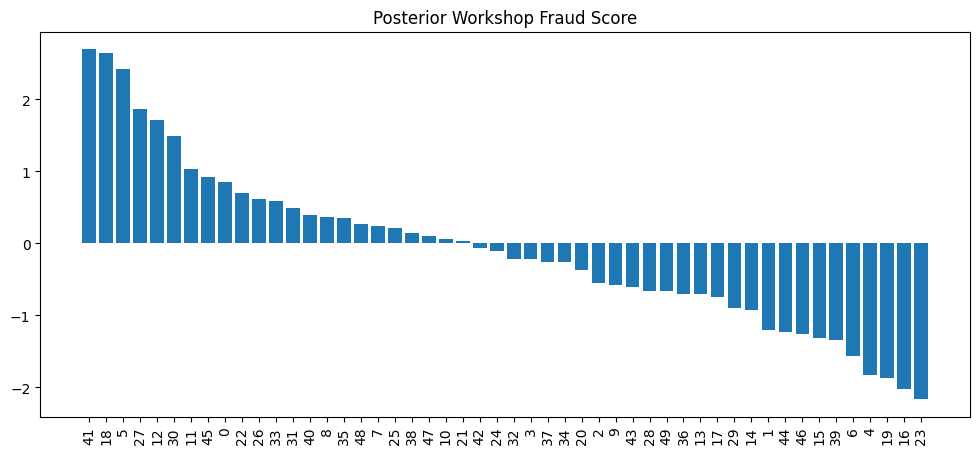

In [10]:
plt.figure(figsize=(12,5))

plt.bar(
    fraud_score["workshop_id"].astype(str),
    fraud_score["fraud_score"]
)

plt.xticks(rotation=90)

plt.title("Posterior Workshop Fraud Score")
plt.show()

In [11]:
# simpan dataframe ke csv
df.to_csv("fraud_claim_dataset.csv", index=False)

print("File berhasil disimpan")

File berhasil disimpan
